# A09 — Transfer Learning com ResNet50 para Classificacao ASTER

**Objetivo:** Aplicar Transfer Learning com backbone pre-treinado (ImageNet) para classificacao binaria de imagens ASTER multiespectrais.

| Item | Detalhe |
|---|---|
| **Modelo** | ResNet50 (pre-treinado ImageNet) |
| **Input ASTER** | 128x128x9 (3 VNIR + 6 SWIR) |
| **Adaptacao** | Conv2d 1x1 (9->3 canais) — adaptador espectral treinavel |
| **Estrategia** | Feature extraction (backbone congelado) + fine-tuning |
| **Framework** | PyTorch + torchvision |

### Arquitetura
```
Input (B, 9, 128, 128)
  -> Conv2d Adapter (9->3) + BN + ReLU
  -> Resize bilinear (224x224)
  -> ResNet50 Encoder (CONGELADO)
  -> AdaptiveAvgPool -> Flatten
  -> Dropout(0.3)
  -> Linear(1) + Sigmoid
```

## 1. Setup e Instalacao

Apenas pacotes padrao do Colab — sem dependencias externas problematicas.

In [1]:
# Tudo ja vem instalado no Colab — so garantir versoes compativeis
!pip install -q --upgrade torch torchvision scikit-learn pandas matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 87.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 111.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 112.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.1 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.1 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.1 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you

## 2. Caminho dos Dados

Os arquivos `pixels_dataset.csv` e `extracted_codes.json` devem estar na pasta de arquivos do Colab (painel lateral esquerdo). Faca upload deles se necessario.

In [2]:
import os

CSV_PATH = '/content/pixels_dataset.csv'
CODES_PATH = '/content/extracted_codes.json'

assert os.path.isfile(CSV_PATH), f'Nao encontrou {CSV_PATH} — faca upload pelo painel lateral'
assert os.path.isfile(CODES_PATH), f'Nao encontrou {CODES_PATH} — faca upload pelo painel lateral'
print('Dados encontrados!')

Dados encontrados!


## 3. Imports e Device

In [3]:
import json
import re

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.v2 as T
import torchvision.models as models
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    f1_score,
)
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: Tesla T4


## 4. Pipeline de Dados

Funcoes de preparacao de dados embutidas no notebook (extraidas de `cnn_data_prep.py`).

In [4]:
def get_ordered_pixel_columns(df, pixel_prefix='pixel_'):
    pixel_cols = [c for c in df.columns if c.startswith(pixel_prefix)]
    if not pixel_cols:
        raise ValueError(f'Nenhuma coluna com prefixo {pixel_prefix}')
    def _sort_key(col):
        suffix = col[len(pixel_prefix):]
        return (0, int(suffix)) if suffix.isdigit() else (1, suffix)
    pixel_cols.sort(key=_sort_key)
    return pixel_cols


def infer_cnn_shape(df, pixel_columns=None, n_channels=None, height=None, width=None):
    pixel_columns = pixel_columns or get_ordered_pixel_columns(df)
    n_pixels_total = len(pixel_columns)
    if n_channels is None and 'count' in df.columns:
        u = df['count'].dropna().unique()
        if len(u) == 1 and int(u[0]) > 0:
            n_channels = int(u[0])
    if height is None and 'height' in df.columns:
        u = df['height'].dropna().unique()
        if len(u) == 1 and int(u[0]) > 0:
            height = int(u[0])
    if width is None and 'width' in df.columns:
        u = df['width'].dropna().unique()
        if len(u) == 1 and int(u[0]) > 0:
            width = int(u[0])
    if n_channels and height and width:
        assert n_channels * height * width == n_pixels_total
        return {'n_channels': n_channels, 'height': height, 'width': width, 'pixels_per_channel': height * width}
    if n_channels and not height:
        ppc = n_pixels_total // n_channels
        side = int(np.sqrt(ppc))
        assert side * side == ppc
        return {'n_channels': n_channels, 'height': side, 'width': side, 'pixels_per_channel': ppc}
    raise ValueError('Nao foi possivel inferir shape. Informe n_channels/height/width.')


def dataframe_to_cnn_tensor(df, pixel_prefix='pixel_', n_channels=None, height=None, width=None):
    pixel_columns = get_ordered_pixel_columns(df, pixel_prefix)
    shape_info = infer_cnn_shape(df, pixel_columns, n_channels, height, width)
    flat = df[pixel_columns].to_numpy(dtype=np.float32, copy=True)
    n_samples = flat.shape[0]
    x = flat.reshape(n_samples, shape_info['n_channels'], shape_info['height'], shape_info['width'])
    x = np.transpose(x, (0, 2, 3, 1))  # channels_last
    return x, shape_info


def labels_from_extracted_codes(paths, codes_path):
    with open(codes_path, 'r') as f:
        codes = json.load(f)
    positives = set(codes.get('positivos', []))
    negatives = set(codes.get('negativos', []))
    all_ids = sorted(positives | negatives, key=len, reverse=True)
    pattern = '|'.join(re.escape(c) for c in all_ids)
    path_series = pd.Series(list(paths), dtype=str)
    image_ids = path_series.str.extract(rf'({pattern})', expand=False)
    labels = np.where(image_ids.isin(positives), 1, np.where(image_ids.isin(negatives), 0, -1)).astype(np.int64)
    image_ids = image_ids.fillna('').to_numpy(dtype=object)
    return labels, image_ids


def fit_channel_normalizer(x, method='zscore', eps=1e-8):
    axes = (0, 1, 2)
    if method == 'zscore':
        mean = x.mean(axis=axes, keepdims=True).astype(np.float32)
        std = x.std(axis=axes, keepdims=True).astype(np.float32)
        std = np.where(std < eps, 1.0, std)
        return {'method': 'zscore', 'mean': mean, 'std': std}
    raise ValueError('method deve ser zscore')


def apply_channel_normalizer(x, normalizer):
    return ((x - normalizer['mean']) / normalizer['std']).astype(np.float32)


def stratified_group_split(image_ids, labels, test_size=0.15, val_size=0.15, seed=42):
    frame = pd.DataFrame({'image_id': np.asarray(image_ids, dtype=str), 'label': np.asarray(labels, dtype=np.int64)})
    frame = frame[frame['image_id'] != ''].copy()
    img_level = frame.groupby('image_id')['label'].agg(lambda v: int(pd.Series(v).mode().iloc[0])).reset_index()
    train_val_ids, test_ids = train_test_split(img_level['image_id'], test_size=test_size, random_state=seed, stratify=img_level['label'])
    tv_frame = img_level[img_level['image_id'].isin(train_val_ids)]
    train_ids, val_ids = train_test_split(tv_frame['image_id'], test_size=val_size/(1-test_size), random_state=seed, stratify=tv_frame['label'])
    ids_arr = np.asarray(image_ids, dtype=object)
    return {
        'train_idx': np.flatnonzero(np.isin(ids_arr, train_ids.to_numpy())),
        'val_idx': np.flatnonzero(np.isin(ids_arr, val_ids.to_numpy())),
        'test_idx': np.flatnonzero(np.isin(ids_arr, test_ids.to_numpy())),
    }


def prepare_data(csv_path, codes_path, test_size=0.15, val_size=0.15, seed=42):
    print('Carregando CSV...')
    df = pd.read_csv(csv_path)
    print(f'  {df.shape[0]} amostras, {df.shape[1]} colunas')
    X, shape_info = dataframe_to_cnn_tensor(df)
    print(f'  Tensor: {X.shape} (N, H, W, C)')
    labels, image_ids = labels_from_extracted_codes(df['path'], codes_path)
    valid = (labels != -1) & (np.asarray(image_ids, dtype=str) != '')
    X, labels, image_ids = X[valid], labels[valid], image_ids[valid]
    print(f'  Validos: {X.shape[0]} (removidos {(~valid).sum()} invalidos)')
    split = stratified_group_split(image_ids, labels, test_size, val_size, seed)
    ti, vi, tei = split['train_idx'], split['val_idx'], split['test_idx']
    result = {
        'X_train': X[ti], 'y_train': labels[ti],
        'X_val': X[vi], 'y_val': labels[vi],
        'X_test': X[tei], 'y_test': labels[tei],
        'shape_info': shape_info,
    }
    for name in ['train', 'val', 'test']:
        y = result[f'y_{name}']
        print(f'  {name:5s}: {result[f"X_{name}"].shape} | classes: {dict(zip(*np.unique(y, return_counts=True)))}')
    return result

print('Funcoes de dados carregadas!')

Funcoes de dados carregadas!


In [5]:
# Carregar e preparar dados
data = prepare_data(CSV_PATH, CODES_PATH)

X_train, y_train = data['X_train'], data['y_train']
X_val, y_val = data['X_val'], data['y_val']
X_test, y_test = data['X_test'], data['y_test']

Carregando CSV...
  295 amostras, 147464 colunas
  Tensor: (295, 128, 128, 9) (N, H, W, C)
  Validos: 295 (removidos 0 invalidos)
  train: (205, 128, 128, 9) | classes: {np.int64(0): np.int64(125), np.int64(1): np.int64(80)}
  val  : (45, 128, 128, 9) | classes: {np.int64(0): np.int64(27), np.int64(1): np.int64(18)}
  test : (45, 128, 128, 9) | classes: {np.int64(0): np.int64(27), np.int64(1): np.int64(18)}


In [6]:
# Normalizacao z-score por canal (estatisticas APENAS do treino)
normalizer = fit_channel_normalizer(X_train, method='zscore')
X_train = apply_channel_normalizer(X_train, normalizer)
X_val = apply_channel_normalizer(X_val, normalizer)
X_test = apply_channel_normalizer(X_test, normalizer)

print('Normalizacao z-score aplicada')
print(f'  Train — min: {X_train.min():.2f}, max: {X_train.max():.2f}, mean: {X_train.mean():.4f}')
print(f'  Val   — min: {X_val.min():.2f}, max: {X_val.max():.2f}, mean: {X_val.mean():.4f}')

Normalizacao z-score aplicada
  Train — min: -1.76, max: 7.66, mean: 0.0000
  Val   — min: -1.76, max: 8.69, mean: -0.0197


## 5. Data Augmentation + PyTorch Dataset

Augmentation aplicado **apenas no treino**:
- `RandomHorizontalFlip` — variacao de orientacao
- `RandomVerticalFlip` — complementa o flip horizontal
- `RandomAffine` — rotacao e translacao leves

In [7]:
class ASTERDataset(Dataset):
    """Dataset PyTorch para chips ASTER multiespectrais (9 bandas)."""

    def __init__(self, X, y, augment=False):
        self.X = torch.from_numpy(X).permute(0, 3, 1, 2).float()
        self.y = torch.from_numpy(y).float()
        self.augment = augment
        if augment:
            self.transform = nn.Sequential(
                T.RandomHorizontalFlip(p=0.5),
                T.RandomVerticalFlip(p=0.5),
                T.RandomAffine(degrees=15, translate=(0.05, 0.05)),
            )

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx]
        if self.augment:
            x = self.transform(x)
        return x, self.y[idx]


train_ds = ASTERDataset(X_train, y_train, augment=True)
val_ds = ASTERDataset(X_val, y_val, augment=False)
test_ds = ASTERDataset(X_test, y_test, augment=False)

BATCH_SIZE = 16
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

batch_x, batch_y = next(iter(train_loader))
print(f'Batch X: {batch_x.shape}  (B, C=9, H=128, W=128)')
print(f'Batch y: {batch_y.shape}  (B,)')
print(f'Augmentation: ativado no treino')

Batch X: torch.Size([16, 9, 128, 128])  (B, C=9, H=128, W=128)
Batch y: torch.Size([16])  (B,)
Augmentation: ativado no treino


## 6. Modelo — ResNet50 + Transfer Learning

**Por que ResNet50?**
- Backbone robusto e bem estudado, pre-treinado em ImageNet (1M+ imagens)
- Funciona direto com torchvision — sem dependencias extras
- Amplamente usado em remote sensing como baseline forte

**Adaptacao espectral:**
- ASTER tem 9 bandas, ResNet espera 3 (RGB)
- Conv2d 1x1 aprende a melhor projecao linear 9 -> 3 canais

In [8]:
class ResNetClassifier(nn.Module):
    """
    Transfer Learning: ASTER 9 bandas -> ResNet50 -> Classificacao Binaria.

    Input (B, 9, 128, 128)
      -> Conv2d 1x1 Adapter (9 -> 3)
      -> BatchNorm + ReLU
      -> Resize bilinear 224x224
      -> ResNet50 Encoder (CONGELADO)
      -> Dropout -> Linear(1)
    """

    def __init__(self, dropout_rate=0.3, freeze_backbone=True):
        super().__init__()

        # 1. Adaptador espectral: 9 bandas ASTER -> 3 canais RGB-like
        self.channel_adapter = nn.Sequential(
            nn.Conv2d(9, 3, kernel_size=1, bias=False),
            nn.BatchNorm2d(3),
            nn.ReLU(inplace=True),
        )

        # 2. Backbone ResNet50 pre-treinado (ImageNet)
        backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

        # Remover a ultima camada FC — queremos apenas features
        self.backbone = nn.Sequential(*list(backbone.children())[:-1])  # ate avgpool
        self.n_features = 2048  # ResNet50 output features

        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        # 3. Head de classificacao
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout_rate),
            nn.Linear(self.n_features, 1),
        )

        total = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f'Backbone: ResNet50 ({"CONGELADO" if freeze_backbone else "TREINAVEL"})')
        print(f'Features dim: {self.n_features}')
        print(f'Total params:     {total:>12,}')
        print(f'Trainable params: {trainable:>12,} ({100*trainable/total:.1f}%)')

    def forward(self, x):
        x = self.channel_adapter(x)                             # (B, 3, 128, 128)
        x = F.interpolate(x, size=(224, 224), mode='bilinear', align_corners=False)  # (B, 3, 224, 224)
        x = self.backbone(x)                                    # (B, 2048, 1, 1)
        x = self.head(x)                                        # (B, 1)
        return x.squeeze(-1)                                    # (B,)

In [9]:
print('Carregando ResNet50 pre-treinado (ImageNet)...\n')
model = ResNetClassifier(dropout_rate=0.3, freeze_backbone=True)
model = model.to(device)
print('\nModelo carregado!')

Carregando ResNet50 pre-treinado (ImageNet)...

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 206MB/s]


Backbone: ResNet50 (CONGELADO)
Features dim: 2048
Total params:       23,510,114
Trainable params:        2,082 (0.0%)

Modelo carregado!


## 7. Teste do Fluxo Completo de Dados

Valida que os dados passam por cada etapa:
1. Input ASTER (9 bandas) -> 2. Adapter (9->3) -> 3. Resize (224) -> 4. ResNet50 -> 5. Predicao

In [10]:
print('=' * 60)
print('TESTE DO FLUXO COMPLETO DE DADOS')
print('=' * 60)

model.eval()
with torch.no_grad():
    test_x, test_y = next(iter(val_loader))
    test_x = test_x.to(device)

    print(f'\n1. Input ASTER:           {test_x.shape}   (B, 9_bandas, 128, 128)')

    adapted = model.channel_adapter(test_x)
    print(f'2. Apos adapter (9->3):   {adapted.shape}   (B, 3_canais_RGB, 128, 128)')

    resized = F.interpolate(adapted, size=(224, 224), mode='bilinear', align_corners=False)
    print(f'3. Apos resize (224x224): {resized.shape}   (B, 3, 224, 224)')

    features = model.backbone(resized)
    print(f'4. Features ResNet50:     {features.shape}   (B, 2048, 1, 1)')

    logits = model.head(features).squeeze(-1)
    print(f'5. Logits:                {logits.shape}')

    probs = torch.sigmoid(logits)
    print(f'6. Probabilidades:        {probs.cpu().numpy()[:5]}')

    output = model(test_x)
    assert output.shape == test_y.to(device).shape, 'Shape mismatch!'

print(f'7. Labels reais:          {test_y.numpy()[:5]}')
print(f'\n{"=" * 60}')
print('FLUXO COMPLETO VALIDADO!')
print(f'{"=" * 60}')

TESTE DO FLUXO COMPLETO DE DADOS

1. Input ASTER:           torch.Size([16, 9, 128, 128])   (B, 9_bandas, 128, 128)
2. Apos adapter (9->3):   torch.Size([16, 3, 128, 128])   (B, 3_canais_RGB, 128, 128)
3. Apos resize (224x224): torch.Size([16, 3, 224, 224])   (B, 3, 224, 224)
4. Features ResNet50:     torch.Size([16, 2048, 1, 1])   (B, 2048, 1, 1)
5. Logits:                torch.Size([16])
6. Probabilidades:        [0.43659705 0.44567126 0.45909902 0.49806347 0.4797249 ]
7. Labels reais:          [0. 0. 0. 0. 1.]

FLUXO COMPLETO VALIDADO!


## 8. Treinamento — Fase 1 (Backbone Congelado)

Apenas **adapter (9->3)** e **head** sao treinados. Backbone ResNet50 congelado.

In [11]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        logits = model(X_b)
        loss = criterion(logits, y_b)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y_b)
        correct += ((torch.sigmoid(logits) > 0.5).float() == y_b).sum().item()
        total += len(y_b)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_probs, all_labels = [], []
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        logits = model(X_b)
        loss = criterion(logits, y_b)
        total_loss += loss.item() * len(y_b)
        probs = torch.sigmoid(logits)
        correct += ((probs > 0.5).float() == y_b).sum().item()
        total += len(y_b)
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(y_b.cpu().numpy())
    probs_arr, labels_arr = np.array(all_probs), np.array(all_labels)
    metrics = {'loss': total_loss/total, 'accuracy': correct/total, 'probs': probs_arr, 'labels': labels_arr}
    try:
        metrics['auc_roc'] = roc_auc_score(labels_arr, probs_arr)
        metrics['f1'] = f1_score(labels_arr, (probs_arr > 0.5).astype(int), average='weighted')
    except ValueError:
        metrics['auc_roc'] = 0.0
        metrics['f1'] = 0.0
    return metrics

In [12]:
EPOCHS = 30
LR = 1e-3
PATIENCE = 7

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)

best_val_loss = float('inf')
patience_counter = 0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_auc': []}

print(f'Epochs: {EPOCHS} | LR: {LR} | Batch: {BATCH_SIZE} | Patience: {PATIENCE}')
print(f'Treinaveis: adapter + head | Backbone: congelado\n')

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val = evaluate(model, val_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val['loss'])
    history['val_acc'].append(val['accuracy'])
    history['val_auc'].append(val['auc_roc'])

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.3f} | "
          f"Val Loss: {val['loss']:.4f} Acc: {val['accuracy']:.3f} AUC: {val['auc_roc']:.3f}")

    if val['loss'] < best_val_loss:
        best_val_loss = val['loss']
        patience_counter = 0
        torch.save(model.state_dict(), 'best_resnet50_model.pt')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'\nEarly stopping na epoch {epoch+1}')
            break

print('\nTreino Fase 1 concluido!')

Epochs: 30 | LR: 0.001 | Batch: 16 | Patience: 7
Treinaveis: adapter + head | Backbone: congelado

Epoch 01/30 | Train Loss: 0.6294 Acc: 0.644 | Val Loss: 0.6064 Acc: 0.911 AUC: 0.947
Epoch 02/30 | Train Loss: 0.5587 Acc: 0.654 | Val Loss: 0.5119 Acc: 0.889 AUC: 0.965
Epoch 03/30 | Train Loss: 0.5361 Acc: 0.741 | Val Loss: 0.4630 Acc: 0.889 AUC: 0.986
Epoch 04/30 | Train Loss: 0.4976 Acc: 0.820 | Val Loss: 0.4384 Acc: 0.889 AUC: 0.965
Epoch 05/30 | Train Loss: 0.4824 Acc: 0.820 | Val Loss: 0.3926 Acc: 0.867 AUC: 0.957
Epoch 06/30 | Train Loss: 0.4953 Acc: 0.780 | Val Loss: 0.3867 Acc: 0.867 AUC: 0.953
Epoch 07/30 | Train Loss: 0.4712 Acc: 0.810 | Val Loss: 0.3839 Acc: 0.867 AUC: 0.957
Epoch 08/30 | Train Loss: 0.4435 Acc: 0.829 | Val Loss: 0.3681 Acc: 0.867 AUC: 0.967
Epoch 09/30 | Train Loss: 0.4807 Acc: 0.780 | Val Loss: 0.3458 Acc: 0.867 AUC: 0.955
Epoch 10/30 | Train Loss: 0.4170 Acc: 0.829 | Val Loss: 0.3848 Acc: 0.867 AUC: 0.963
Epoch 11/30 | Train Loss: 0.4463 Acc: 0.820 | Val L

## 9. Avaliacao no Conjunto de Teste

In [13]:
model.load_state_dict(torch.load('best_resnet50_model.pt', map_location=device))
test_metrics = evaluate(model, test_loader, criterion, device)

print('=' * 60)
print('RESULTADOS — CONJUNTO DE TESTE')
print('=' * 60)
print(f"Accuracy:  {test_metrics['accuracy']:.4f}")
print(f"F1-Score:  {test_metrics['f1']:.4f}")
print(f"AUC-ROC:   {test_metrics['auc_roc']:.4f}")

y_pred = (test_metrics['probs'] > 0.5).astype(int)
print(f"\n{classification_report(test_metrics['labels'], y_pred, target_names=['Negativo', 'Positivo'])}")

cm = confusion_matrix(test_metrics['labels'], y_pred)
print(f'Confusion Matrix:\n{cm}')

RESULTADOS — CONJUNTO DE TESTE
Accuracy:  0.9333
F1-Score:  0.9339
AUC-ROC:   0.9733

              precision    recall  f1-score   support

    Negativo       1.00      0.89      0.94        27
    Positivo       0.86      1.00      0.92        18

    accuracy                           0.93        45
   macro avg       0.93      0.94      0.93        45
weighted avg       0.94      0.93      0.93        45

Confusion Matrix:
[[24  3]
 [ 0 18]]


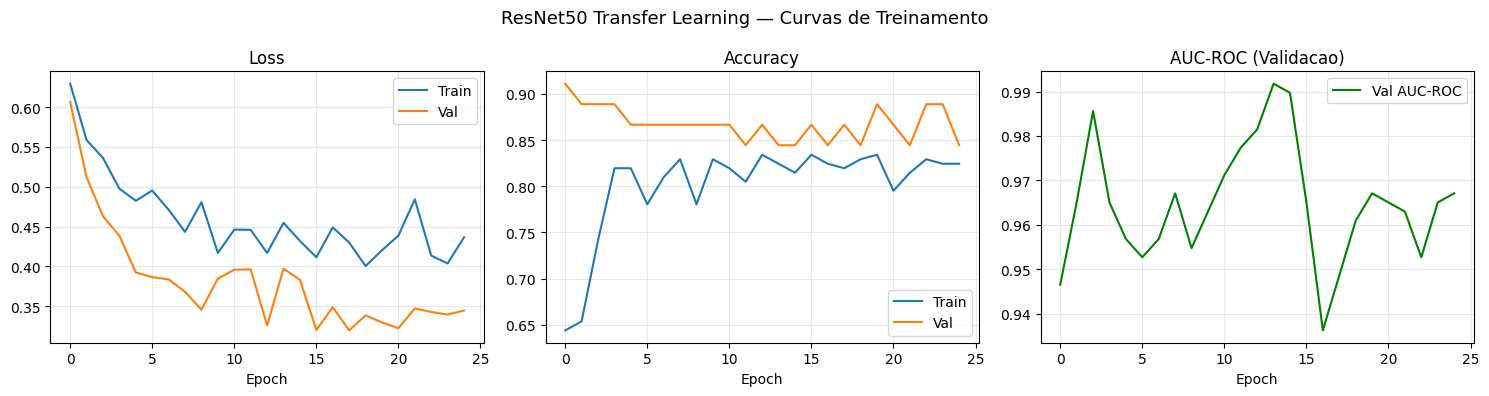

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_acc'], label='Train')
axes[1].plot(history['val_acc'], label='Val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(history['val_auc'], label='Val AUC-ROC', color='green')
axes[2].set_title('AUC-ROC (Validacao)')
axes[2].set_xlabel('Epoch')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

fig.suptitle('ResNet50 Transfer Learning — Curvas de Treinamento', fontsize=13)
plt.tight_layout()
plt.show()

## 10. Resumo do Pipeline

```
Upload (pixels_dataset.csv + extracted_codes.json)
  |  prepare_data()
  v
Tensores numpy (N, 128, 128, 9) — channels_last
  |  fit/apply_channel_normalizer() — z-score por canal
  v
ASTERDataset — permute -> (N, 9, 128, 128) channels_first
  |  Augmentation: RandomFlip + RandomAffine (treino)
  v
DataLoader PyTorch (batches de 16)
  |  ResNetClassifier.forward():
  |    1. Conv2d 1x1 adapter (9 -> 3 canais)
  |    2. Resize bilinear (128 -> 224)
  |    3. ResNet50 encoder (CONGELADO)
  |    4. Dropout + Linear(1)
  v
Probabilidade [0, 1] — classificacao binaria ETR
```